 # BÀI THỰC HÀNH DỮ LIỆU RETAIL

# 1. Chuẩn bị dữ liệu cho trực quan hóa dữ liệu

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu Online Retail
retail_data = pd.read_csv("Online_Retail.csv")

# Giữ lại các cột quan trọng tương tự ví dụ về chim cánh cụt
retail_data = retail_data[['Country', 'UnitPrice']]

# Xem trước 5 dòng đầu tiên
print(retail_data.head())
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc toàn bộ dữ liệu từ file CSV
retail_data = pd.read_csv("Online_Retail.csv")

# Hiển thị tất cả các cột nhưng chỉ 5 dòng đầu
retail_data.head(5)






          Country  UnitPrice
0  United Kingdom       2.55
1  United Kingdom       3.39
2  United Kingdom       2.75
3  United Kingdom       3.39
4  United Kingdom       3.39


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# 2. Trực quan hóa dữ liệu với thư viện Matplotlib


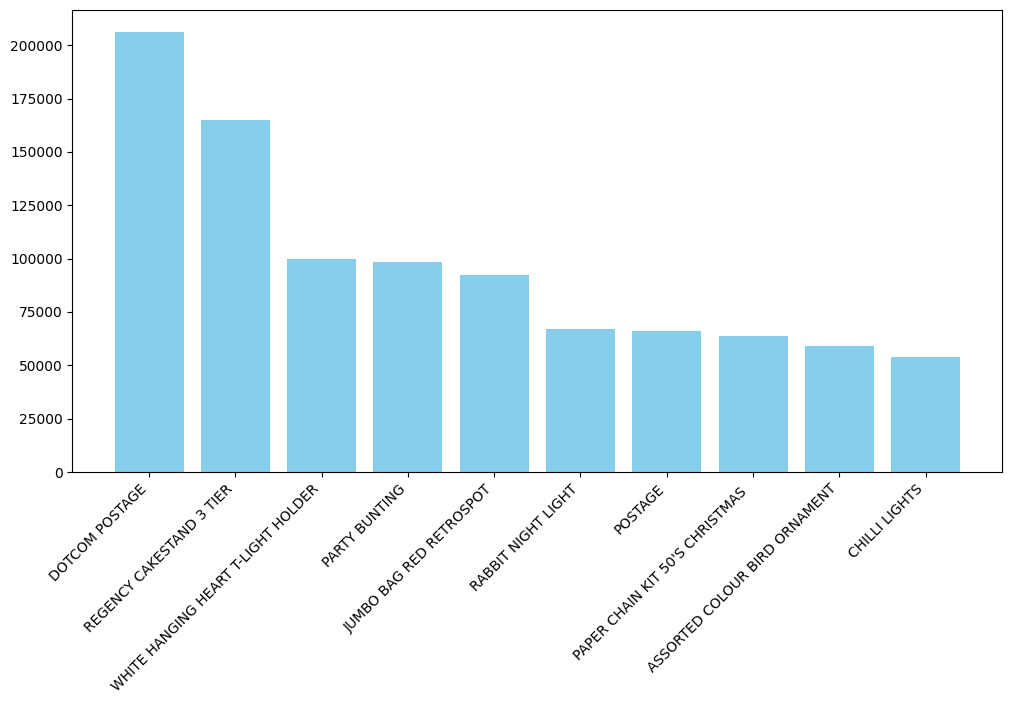

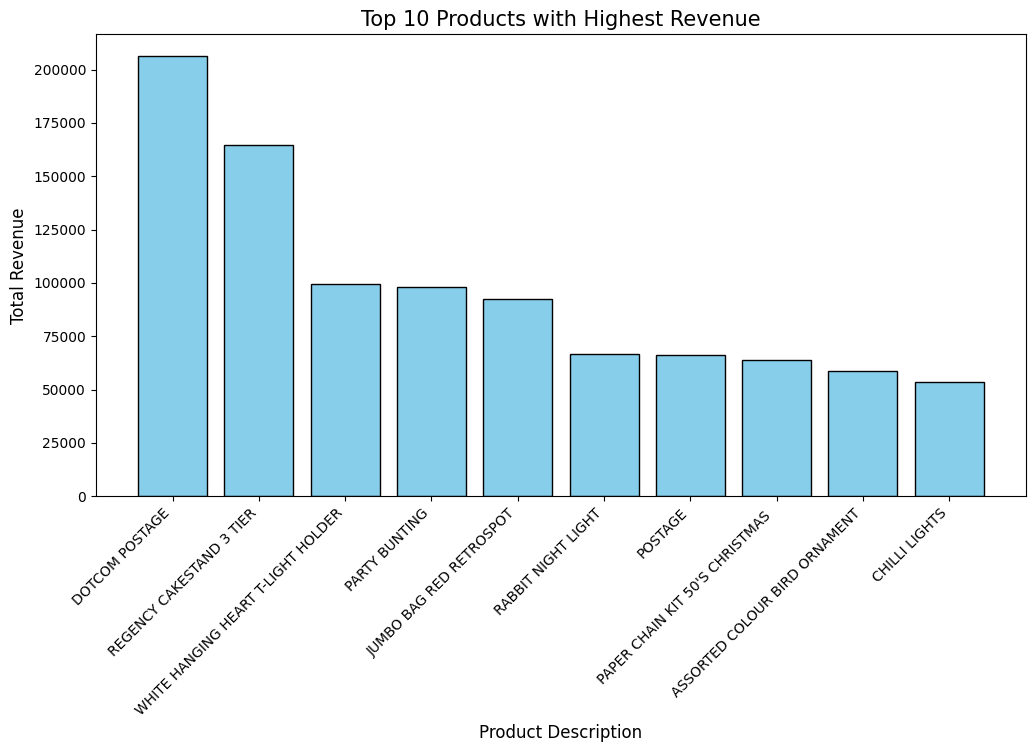

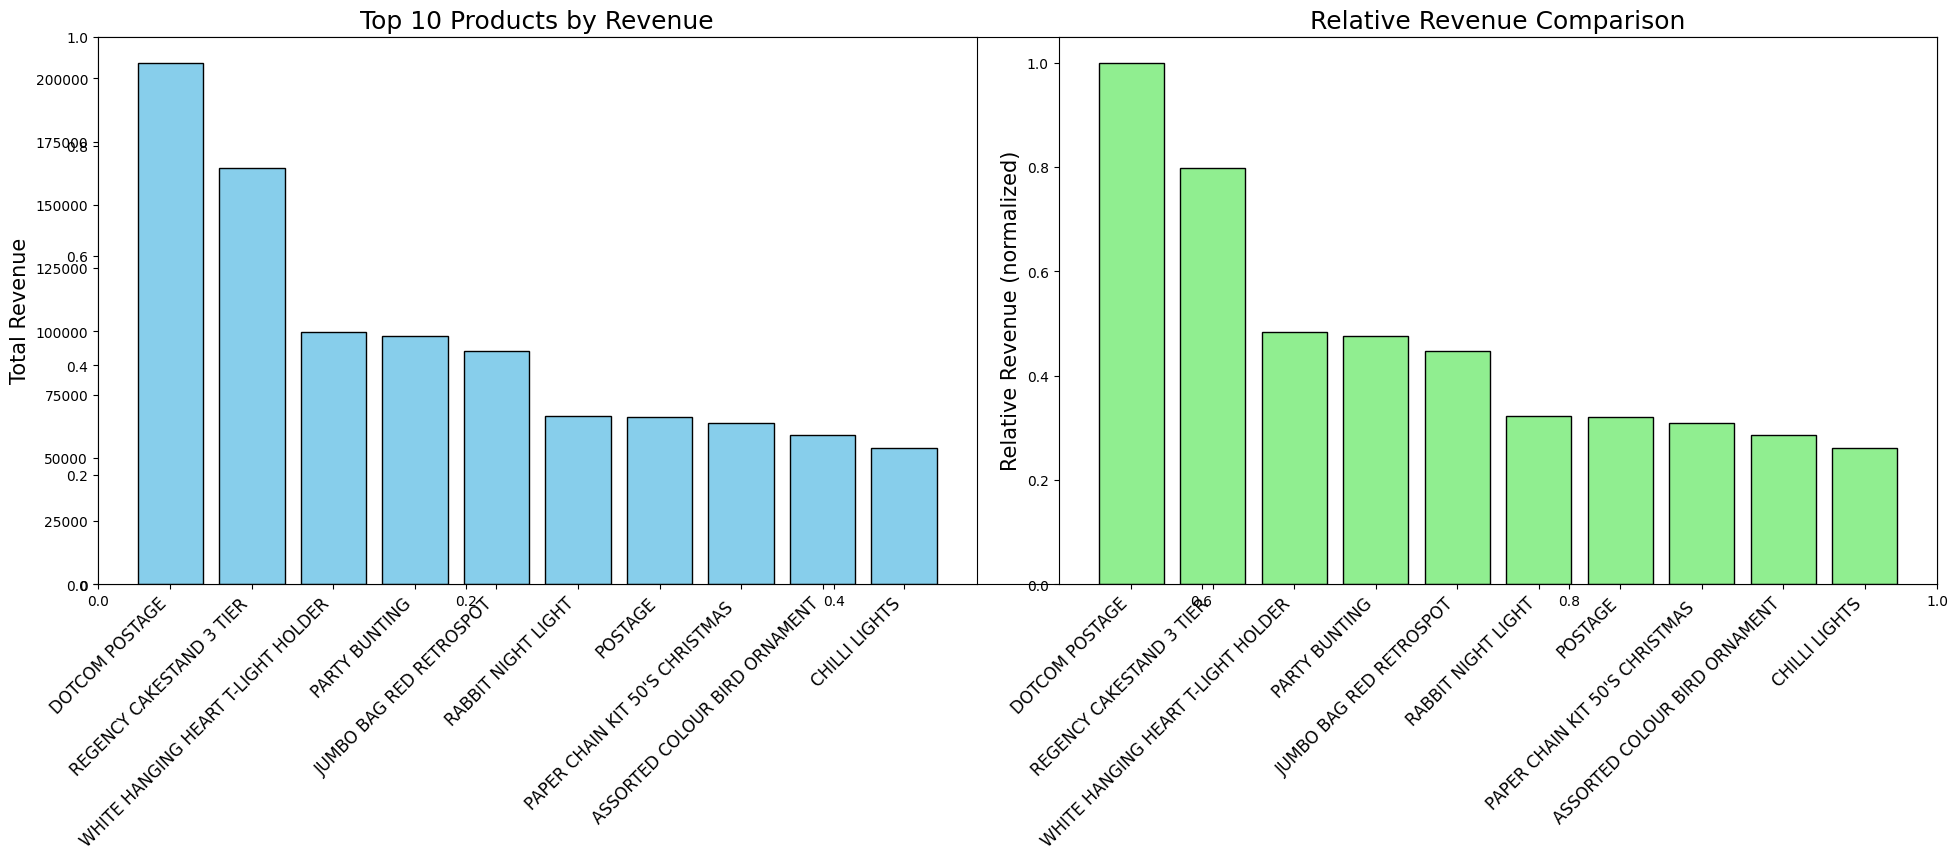

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu
retail_data = pd.read_csv("Online_Retail.csv")

# Tạo cột doanh thu = Quantity * UnitPrice
retail_data['Revenue'] = retail_data['Quantity'] * retail_data['UnitPrice']

# Gom nhóm theo sản phẩm và tính tổng doanh thu
product_revenue = retail_data.groupby('Description')['Revenue'].sum().reset_index()

# Sắp xếp giảm dần theo doanh thu
product_revenue_sorted = product_revenue.sort_values('Revenue', ascending=False)

# Lấy top 10 sản phẩm
top10 = product_revenue_sorted.head(10)

# CASE 1: BASIC
plt.figure(figsize=(12,6))
plt.bar(top10['Description'], top10['Revenue'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.show()

# CASE 2: ADVANCED 1
plt.figure(figsize=(12,6))
plt.bar(top10['Description'], top10['Revenue'], color='skyblue', edgecolor='black')
plt.title('Top 10 Products with Highest Revenue', fontsize=15)
plt.xlabel('Product Description', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# CASE 3: ADVANCED 2
fig, ax = plt.subplots(figsize=(20,9))

# Chia biểu đồ thành 2 phần (nếu muốn so sánh)
plt.subplot(1,2,1)
plt.bar(top10['Description'], top10['Revenue'], color='skyblue', edgecolor='black')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.ylabel('Total Revenue', fontsize=15)
plt.title('Top 10 Products by Revenue', fontsize=18)

plt.subplot(1,2,2)
plt.bar(top10['Description'], top10['Revenue']/top10['Revenue'].max(), color='lightgreen', edgecolor='black')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.ylabel('Relative Revenue (normalized)', fontsize=15)
plt.title('Relative Revenue Comparison', fontsize=18)

plt.tight_layout()
plt.show()



# 3. Trực quan hóa dữ liệu với thư viện Seaborn


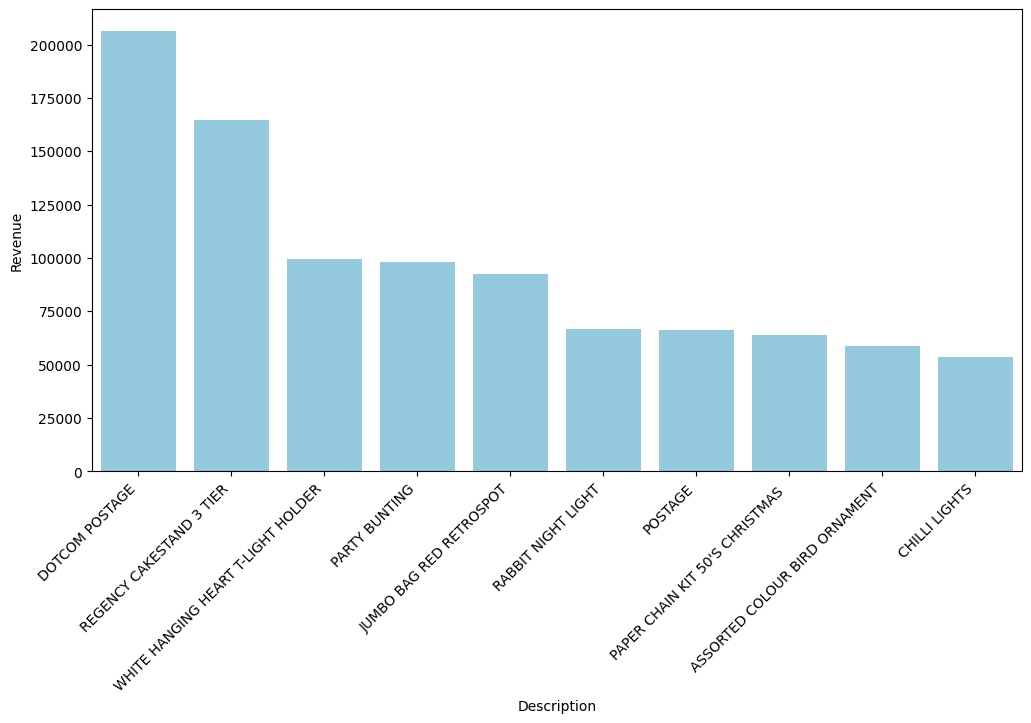

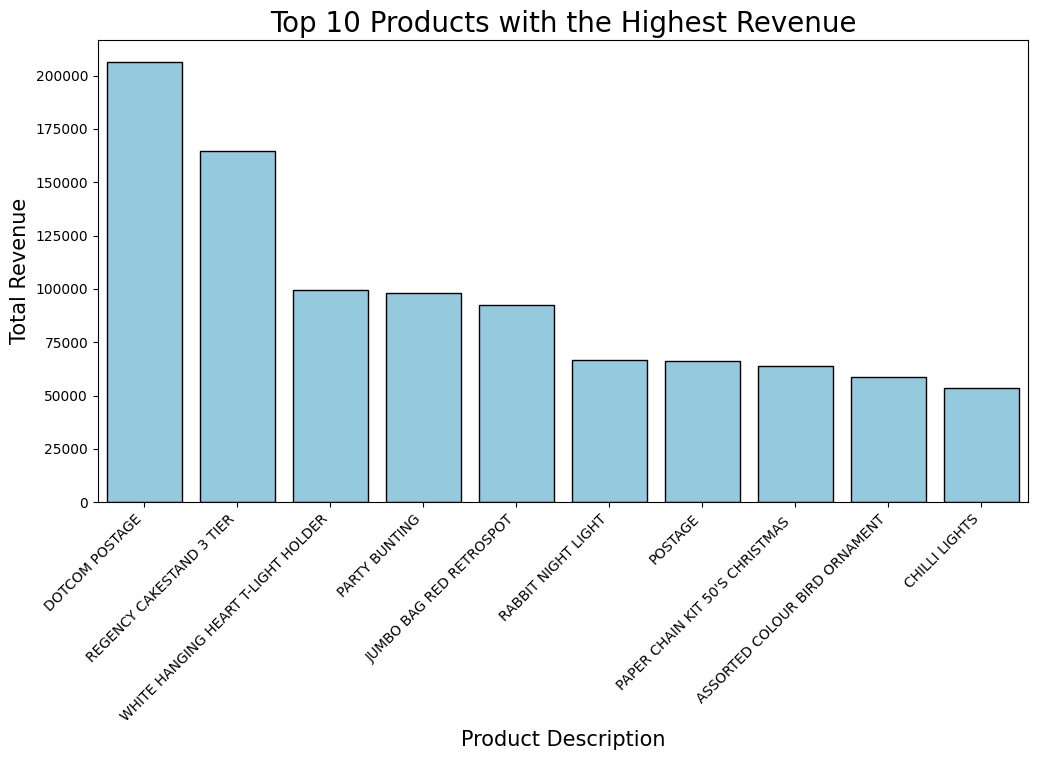

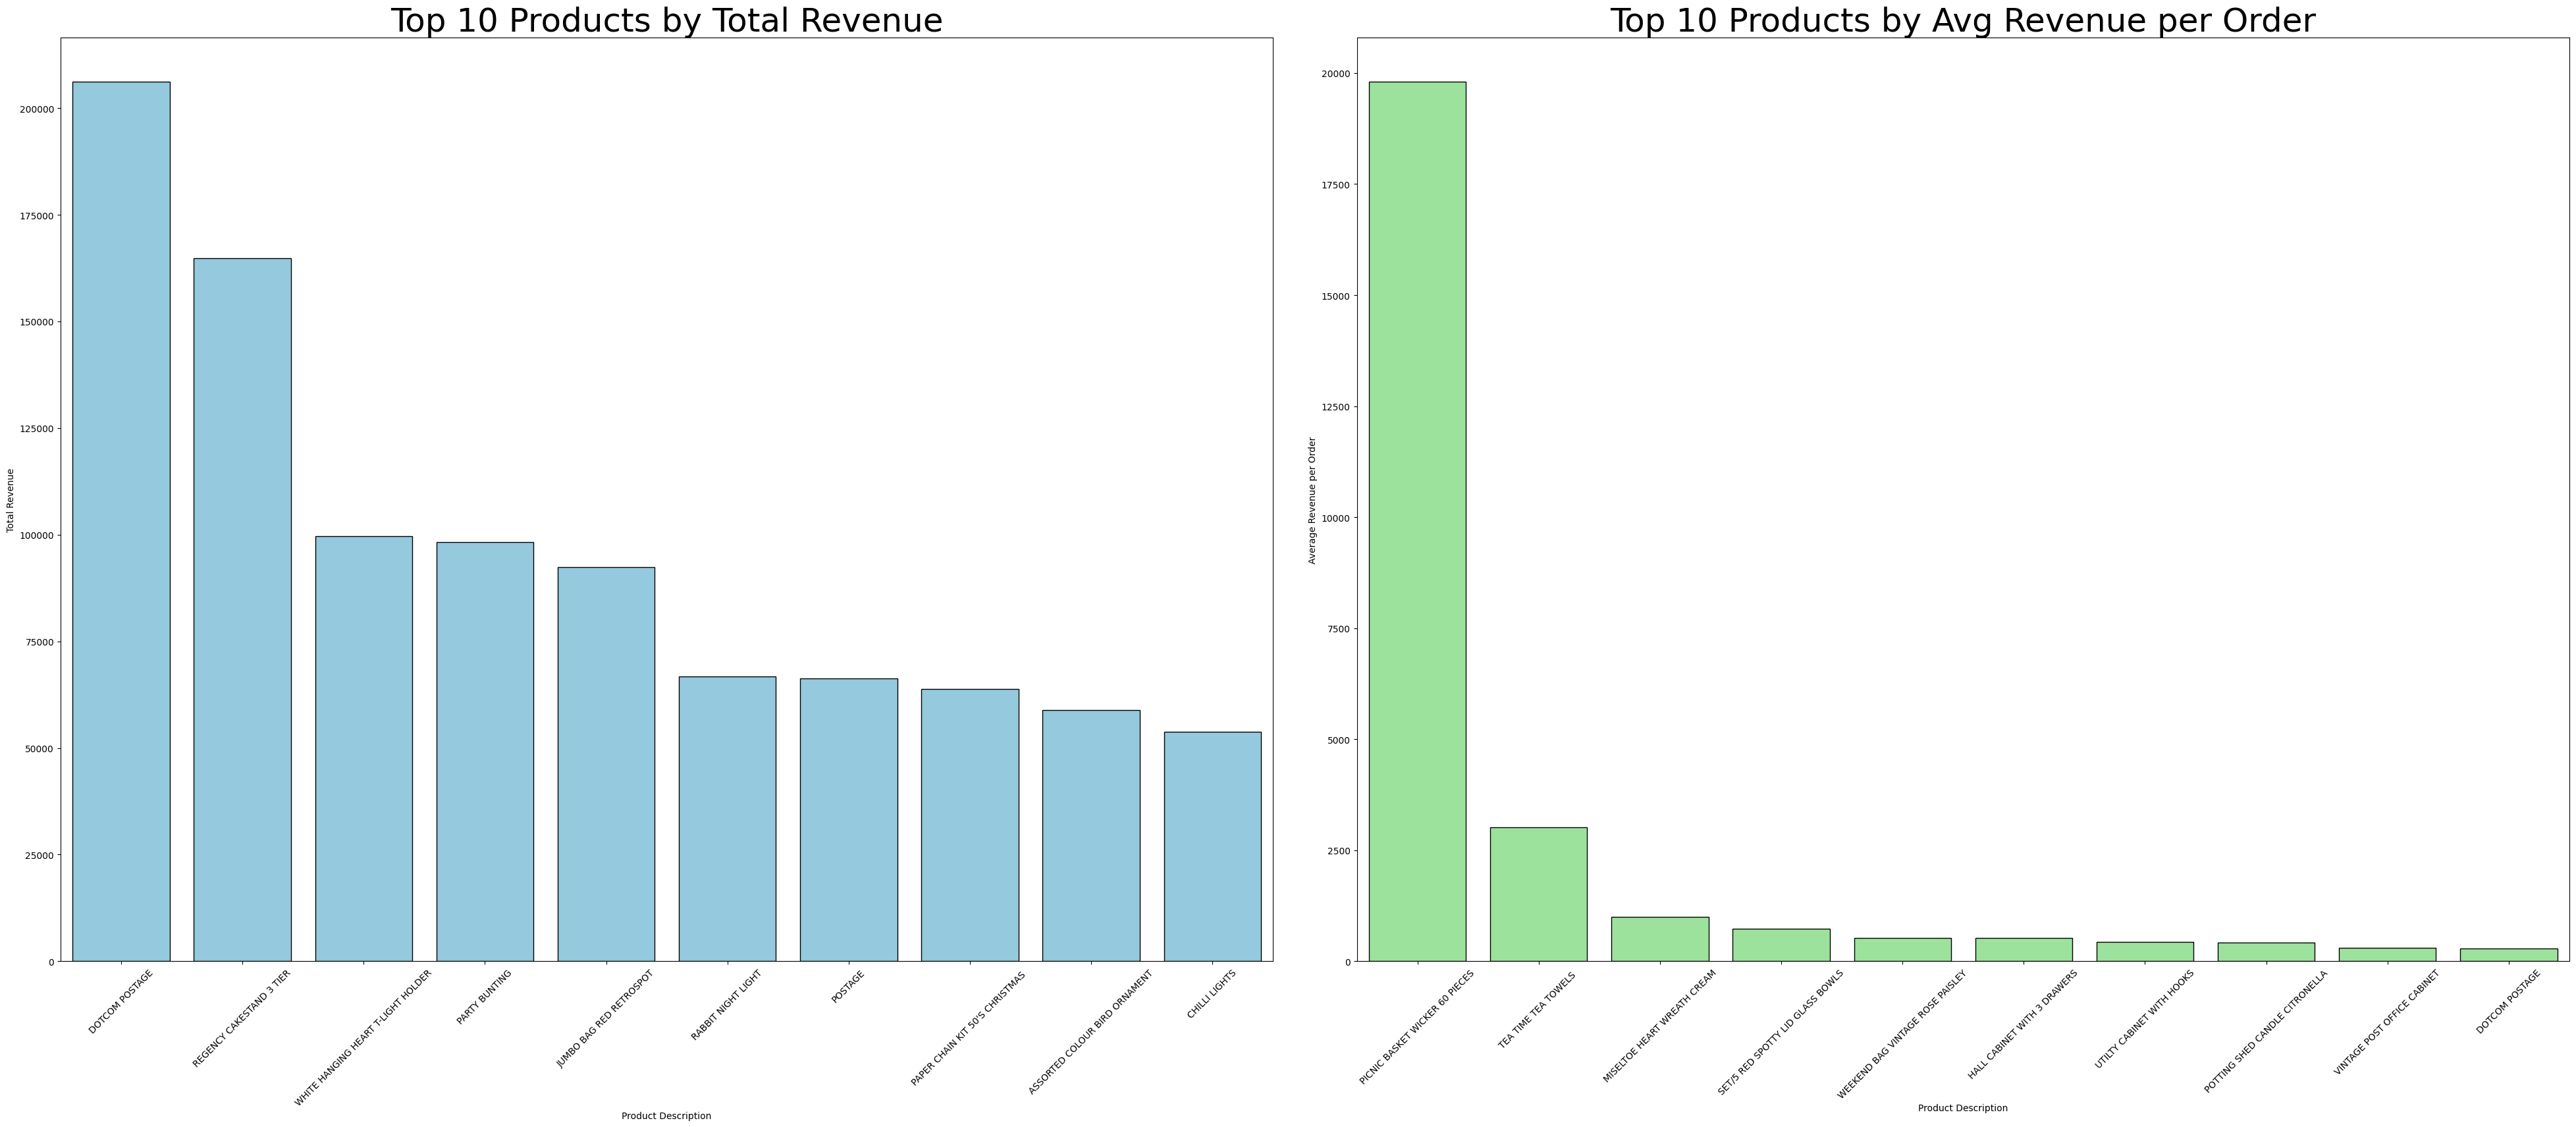

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
retail_data = pd.read_csv("Online_Retail.csv")

# Tạo cột doanh thu (Revenue = Quantity * UnitPrice)
retail_data['Revenue'] = retail_data['Quantity'] * retail_data['UnitPrice']

# Gom nhóm theo sản phẩm (Description) và tính tổng doanh thu
product_revenue = retail_data.groupby('Description')['Revenue'].sum().reset_index()

# Sắp xếp giảm dần theo doanh thu
product_revenue_sorted = product_revenue.sort_values('Revenue', ascending=False)

# CASE 1: BASIC
plt.figure(figsize=(12,6))
data = product_revenue_sorted.head(10)
sns.barplot(data=data, x='Description', y='Revenue', color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.show()

# CASE 2: ADVANCED 1
plt.figure(figsize=(12,6))
data = product_revenue_sorted.head(10)
ax = sns.barplot(data=data, x='Description', y='Revenue', color='skyblue', edgecolor='black')
ax.set_xlabel('Product Description', fontsize=15)
ax.set_ylabel('Total Revenue', fontsize=15)
ax.set_title('Top 10 Products with the Highest Revenue', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.show()

# CASE 3: VIEW MULTIPLE PERSPECTIVES
fig, ax = plt.subplots(1, 2, figsize=(40,18))
data = product_revenue_sorted.head(10)
sns.set(font_scale=3)

# Biểu đồ 1: Tổng doanh thu
ax1 = sns.barplot(data=data, x='Description', y='Revenue', ax=ax[0], color='skyblue', edgecolor='black')
ax1.set_xlabel('Product Description')
ax1.set_ylabel('Total Revenue')
ax1.set_title('Top 10 Products by Total Revenue')
ax1.tick_params(axis='x', rotation=45)

# Biểu đồ 2: Doanh thu trung bình mỗi đơn hàng
product_avg = retail_data.groupby('Description')['Revenue'].mean().reset_index()
product_avg_sorted = product_avg.sort_values('Revenue', ascending=False).head(10)
ax2 = sns.barplot(data=product_avg_sorted, x='Description', y='Revenue', ax=ax[1], color='lightgreen', edgecolor='black')
ax2.set_xlabel('Product Description')
ax2.set_ylabel('Average Revenue per Order')
ax2.set_title('Top 10 Products by Avg Revenue per Order')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# KẾT THÚC